In [3]:
import pandas as pd

# The USDA file is in the parent folder's 'data' directory
xl = pd.ExcelFile('../data/FoodAccessResearchAtlasData2019.xlsx')
print("Available sheets:")
for s in xl.sheet_names:
    print(f"  - {s}")

Available sheets:
  - Read Me
  - Variable Lookup
  - Food Access Research Atlas


In [4]:
df = pd.read_excel('../data/FoodAccessResearchAtlasData2019.xlsx', 
                   sheet_name='Food Access Research Atlas')

print(f"Shape: {df.shape}")
df.head(3)

Shape: (72531, 147)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,221.0,1622.0,217.0,14.0,0.0,14.0,45.0,44.0,6.0,102.0
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,214.0,888.0,1217.0,5.0,0.0,5.0,55.0,75.0,89.0,156.0
2,1001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,439.0,2576.0,647.0,17.0,5.0,11.0,117.0,87.0,99.0,172.0


In [5]:
# Filter to Maricopa County (Arizona FIPS 04, Maricopa FIPS 013)
maricopa = df[df['CensusTract'].astype(str).str.startswith('04013')]
print(f"Maricopa tracts in USDA data: {len(maricopa)}")

# Scan all 147 columns for ones we care about
print("\nRelevant columns:")
for col in df.columns:
    if any(x in col.lower() for x in ['income', 'poverty', 'pop2010', 'lila', 'urban', 'tractlowi', 'housing']):
        print(f"  - {col}")

Maricopa tracts in USDA data: 0

Relevant columns:
  - Urban
  - Pop2010
  - LILATracts_1And10
  - LILATracts_halfAnd10
  - LILATracts_1And20
  - LILATracts_Vehicle
  - LowIncomeTracts
  - PovertyRate
  - MedianFamilyIncome
  - TractLOWI


In [6]:
# Check the data type and a sample
print(f"CensusTract dtype: {df['CensusTract'].dtype}")
print(f"Sample values:")
print(df['CensusTract'].head())
print(f"\nArizona sample (State=Arizona):")
print(df[df['State'] == 'Arizona']['CensusTract'].head())

CensusTract dtype: int64
Sample values:
0    1001020100
1    1001020200
2    1001020300
3    1001020400
4    1001020500
Name: CensusTract, dtype: int64

Arizona sample (State=Arizona):
1345    4001942600
1346    4001942700
1347    4001944000
1348    4001944100
1349    4001944201
Name: CensusTract, dtype: int64


In [7]:
# Filter using State + County directly (more reliable than GEOID parsing)
maricopa = df[(df['State'] == 'Arizona') & (df['County'] == 'Maricopa County')]
print(f"Maricopa tracts in USDA data: {len(maricopa)}")

# Also add a padded GEOID column for joining later
maricopa = maricopa.copy()
maricopa['GEOID'] = maricopa['CensusTract'].astype(str).str.zfill(11)
print(f"\nSample GEOIDs (padded to 11 digits):")
print(maricopa['GEOID'].head())

Maricopa tracts in USDA data: 913

Sample GEOIDs (padded to 11 digits):
1457    04013010101
1458    04013010102
1459    04013030401
1460    04013030402
1461    04013040502
Name: GEOID, dtype: object


In [8]:
# USDA's official "Low-Income Low-Access" flag (at 1-mile urban / 10-mile rural)
# 1 = tract is a food desert per USDA definition, 0 = not

print("=" * 60)
print("MARICOPA COUNTY FOOD ACCESS — KEY STATS")
print("=" * 60)

lila_count = maricopa['LILATracts_1And10'].sum()
total = len(maricopa)
print(f"\nTotal Maricopa tracts: {total}")
print(f"USDA-classified food deserts (LILA 1&10): {int(lila_count)} ({lila_count/total*100:.1f}%)")

# Compare median income: food desert vs not
fd = maricopa[maricopa['LILATracts_1And10'] == 1]
nfd = maricopa[maricopa['LILATracts_1And10'] == 0]

fd_income = fd['MedianFamilyIncome'].median()
nfd_income = nfd['MedianFamilyIncome'].median()
diff_pct = (nfd_income - fd_income) / nfd_income * 100

print(f"\n{'Metric':<35} {'Food Desert':>12} {'Served':>12}")
print("-" * 60)
print(f"{'Tracts':<35} {len(fd):>12} {len(nfd):>12}")
print(f"{'Median household income':<35} ${fd_income:>11,.0f} ${nfd_income:>11,.0f}")
print(f"{'Median poverty rate':<35} {fd['PovertyRate'].median():>11.1f}% {nfd['PovertyRate'].median():>11.1f}%")
print(f"{'Total population (2010)':<35} {int(fd['Pop2010'].sum()):>12,} {int(nfd['Pop2010'].sum()):>12,}")

print(f"\n→ Food desert tracts earn {diff_pct:.0f}% less than served tracts")
print(f"→ {int(fd['Pop2010'].sum()):,} Maricopa residents live in USDA-classified food deserts")

MARICOPA COUNTY FOOD ACCESS — KEY STATS

Total Maricopa tracts: 913
USDA-classified food deserts (LILA 1&10): 97 (10.6%)

Metric                               Food Desert       Served
------------------------------------------------------------
Tracts                                        97          816
Median household income             $     45,584 $     74,250
Median poverty rate                        25.2%        10.0%
Total population (2010)                  374,746    3,442,371

→ Food desert tracts earn 39% less than served tracts
→ 374,746 Maricopa residents live in USDA-classified food deserts


In [9]:
# Save the Maricopa income + classification data as CSV for QGIS join
cols_to_keep = ['GEOID', 'CensusTract', 'State', 'County', 
                'Urban', 'Pop2010', 'LowIncomeTracts', 'PovertyRate',
                'MedianFamilyIncome', 'LILATracts_1And10', 
                'LILATracts_halfAnd10', 'LILATracts_Vehicle']

maricopa_clean = maricopa[cols_to_keep].copy()
maricopa_clean.to_csv('../data/maricopa_income.csv', index=False)

print(f"Saved {len(maricopa_clean)} rows to maricopa_income.csv")
print(f"\nColumns saved:")
for c in maricopa_clean.columns:
    print(f"  - {c}")
print(f"\nFirst 3 rows:")
maricopa_clean.head(3)

Saved 913 rows to maricopa_income.csv

Columns saved:
  - GEOID
  - CensusTract
  - State
  - County
  - Urban
  - Pop2010
  - LowIncomeTracts
  - PovertyRate
  - MedianFamilyIncome
  - LILATracts_1And10
  - LILATracts_halfAnd10
  - LILATracts_Vehicle

First 3 rows:


,GEOID,CensusTract,State,County,Urban,Pop2010,LowIncomeTracts,PovertyRate,MedianFamilyIncome,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle
1457,04013010101,4013010101,Arizona,Maricopa County,0,5073,0,4.286013,97143.0,0,0,0
1458,04013010102,4013010102,Arizona,Maricopa County,1,4640,0,7.798892,152710.0,0,0,0
1459,04013030401,4013030401,Arizona,Maricopa County,1,4283,0,3.022366,133063.0,0,0,0


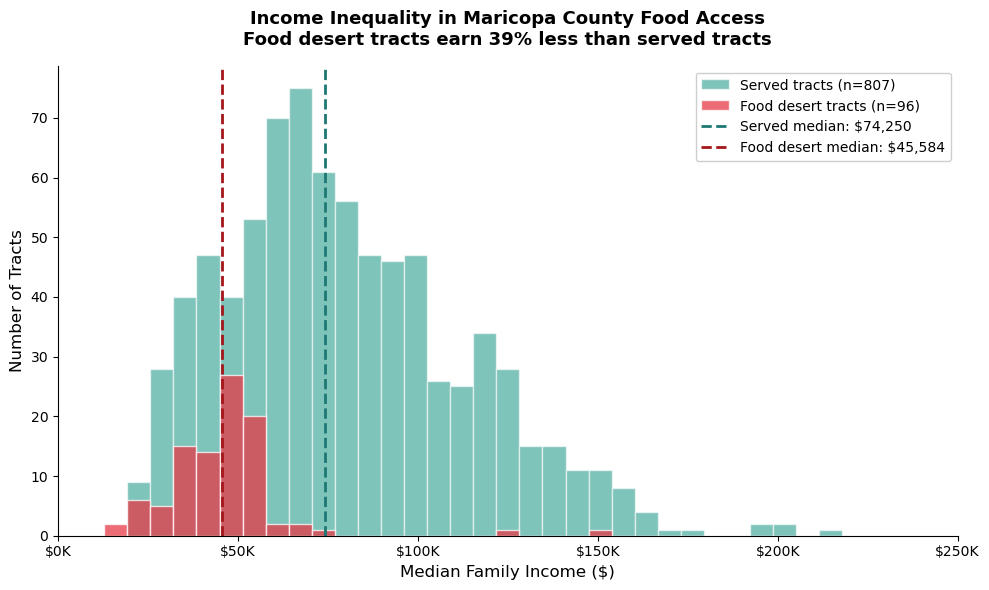

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Clean the data — drop NaN incomes
fd = maricopa[maricopa['LILATracts_1And10'] == 1]['MedianFamilyIncome'].dropna()
nfd = maricopa[maricopa['LILATracts_1And10'] == 0]['MedianFamilyIncome'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram with transparent overlap
bins = np.linspace(0, 250000, 40)
ax.hist(nfd, bins=bins, alpha=0.6, label=f'Served tracts (n={len(nfd)})', 
        color='#2a9d8f', edgecolor='white')
ax.hist(fd, bins=bins, alpha=0.75, label=f'Food desert tracts (n={len(fd)})', 
        color='#e63946', edgecolor='white')

# Median markers
ax.axvline(nfd.median(), color='#1d7874', linestyle='--', linewidth=2, 
           label=f'Served median: ${nfd.median():,.0f}')
ax.axvline(fd.median(), color='#a4161a', linestyle='--', linewidth=2, 
           label=f'Food desert median: ${fd.median():,.0f}')

ax.set_xlabel('Median Family Income ($)', fontsize=12)
ax.set_ylabel('Number of Tracts', fontsize=12)
ax.set_title('Income Inequality in Maricopa County Food Access\n' + 
             'Food desert tracts earn 39% less than served tracts',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 250000)

# Format x-axis as dollars
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../maps/income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

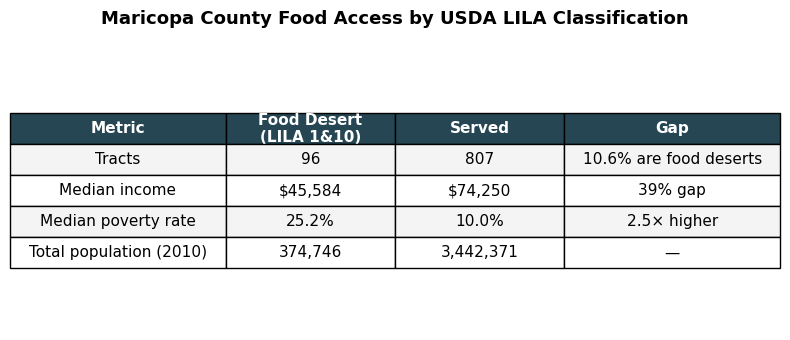

In [12]:
# A clean comparison table as a matplotlib figure
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('off')

table_data = [
    ['Metric', 'Food Desert\n(LILA 1&10)', 'Served', 'Gap'],
    ['Tracts', f'{len(fd)}', f'{len(nfd)}', f'{len(fd)/(len(fd)+len(nfd))*100:.1f}% are food deserts'],
    ['Median income', f'${fd.median():,.0f}', f'${nfd.median():,.0f}', f'{(nfd.median()-fd.median())/nfd.median()*100:.0f}% gap'],
    ['Median poverty rate', 
     f"{maricopa[maricopa['LILATracts_1And10']==1]['PovertyRate'].median():.1f}%",
     f"{maricopa[maricopa['LILATracts_1And10']==0]['PovertyRate'].median():.1f}%",
     '2.5× higher'],
    ['Total population (2010)', 
     f"{int(maricopa[maricopa['LILATracts_1And10']==1]['Pop2010'].sum()):,}",
     f"{int(maricopa[maricopa['LILATracts_1And10']==0]['Pop2010'].sum()):,}",
     '—'],
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                 colWidths=[0.28, 0.22, 0.22, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header
for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor('#264653')
    cell.set_text_props(weight='bold', color='white')

# Alternating row colors
for row in range(1, 5):
    for col in range(4):
        if row % 2 == 1:
            table[(row, col)].set_facecolor('#f4f4f4')

ax.set_title('Maricopa County Food Access by USDA LILA Classification', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../maps/summary_table.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [13]:
# Urban vs rural breakdown of food deserts
urban_fd = maricopa[(maricopa['LILATracts_1And10']==1) & (maricopa['Urban']==1)]
rural_fd = maricopa[(maricopa['LILATracts_1And10']==1) & (maricopa['Urban']==0)]

print("=" * 60)
print("URBAN vs RURAL FOOD DESERT BREAKDOWN")
print("=" * 60)
print(f"\nOf {len(fd)} food desert tracts in Maricopa County:")
print(f"  • {len(urban_fd)} are URBAN ({len(urban_fd)/len(fd)*100:.0f}%)")
print(f"  • {len(rural_fd)} are RURAL ({len(rural_fd)/len(fd)*100:.0f}%)")

print(f"\nPopulation affected:")
print(f"  • Urban food deserts: {int(urban_fd['Pop2010'].sum()):,} residents")
print(f"  • Rural food deserts: {int(rural_fd['Pop2010'].sum()):,} residents")

print(f"\nThis matters because:")
print(f"  Urban food deserts = systemic inequality (many people, no stores nearby)")
print(f"  Rural food deserts = low density (few people, stores far but car-dependent)")

print(f"\n→ {int(urban_fd['Pop2010'].sum()):,} urban Maricopa residents lack walkable grocery access")

URBAN vs RURAL FOOD DESERT BREAKDOWN

Of 96 food desert tracts in Maricopa County:
  • 93 are URBAN (97%)
  • 4 are RURAL (4%)

Population affected:
  • Urban food deserts: 358,946 residents
  • Rural food deserts: 15,800 residents

This matters because:
  Urban food deserts = systemic inequality (many people, no stores nearby)
  Rural food deserts = low density (few people, stores far but car-dependent)

→ 358,946 urban Maricopa residents lack walkable grocery access


In [14]:
# This preserves the leading zero

cols = maricopa_clean.columns.tolist()
types = []
for col in cols:
    if col in ['GEOID', 'CensusTract', 'State', 'County']:
        types.append('"String"')
    elif col in ['Urban', 'Pop2010', 'LowIncomeTracts', 'LILATracts_1And10', 
                 'LILATracts_halfAnd10', 'LILATracts_Vehicle']:
        types.append('"Integer"')
    else:  # MedianFamilyIncome, PovertyRate
        types.append('"Real"')

with open('../data/maricopa_income.csvt', 'w') as f:
    f.write(','.join(types))

print("✅ Created maricopa_income.csvt")
print(f"Columns: {cols}")
print(f"Types:   {types}")

✅ Created maricopa_income.csvt
Columns: ['GEOID', 'CensusTract', 'State', 'County', 'Urban', 'Pop2010', 'LowIncomeTracts', 'PovertyRate', 'MedianFamilyIncome', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_Vehicle']
Types:   ['"String"', '"String"', '"String"', '"String"', '"Integer"', '"Integer"', '"Integer"', '"Real"', '"Real"', '"Integer"', '"Integer"', '"Integer"']


In [15]:
# Re-save the CSV with GEOID as zero-padded string
maricopa_clean['GEOID'] = maricopa_clean['GEOID'].astype(str).str.zfill(11)
maricopa_clean['CensusTract'] = maricopa_clean['CensusTract'].astype(str).str.zfill(11)

maricopa_clean.to_csv('../data/maricopa_income.csv', index=False)
print("✅ Re-saved CSV with zero-padded GEOID")
print(maricopa_clean[['GEOID', 'CensusTract']].head())

✅ Re-saved CSV with zero-padded GEOID
            GEOID  CensusTract
1457  04013010101  04013010101
1458  04013010102  04013010102
1459  04013030401  04013030401
1460  04013030402  04013030402
1461  04013040502  04013040502
